# Visualisation du dataset

1. Exemples d'images, avec la boîte et le nom de chaque carte
2. Les déformations, une par une : ce que fait chaque étape de `scene.py`
3. Statistiques : cartes par image, apparitions de chaque carte, tailles des boîtes

Prérequis : `python -m scratch.dataset_generation.assets` puis `python -m scratch.dataset_generation.generate_dataset`.

In [1]:
import os
import sys
while not os.path.isdir(".git"):  # remonte jusqu'à la racine du repo, pour que le chemin data/ fonctionne
    os.chdir("..")
sys.path.insert(0, os.getcwd())  # pour pouvoir importer scratch.dataset_generation

import json
from collections import Counter

import matplotlib.patches as patches
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "data/synthetic"
SPLIT = "train"
annotations = json.load(open(f"{DATA_DIR}/{SPLIT}/annotations.json"))
items = annotations["items"]
print(f"{len(items)} images, {sum(len(item['cards']) for item in items)} cartes")

300 images, 741 cartes


## 1. Exemples

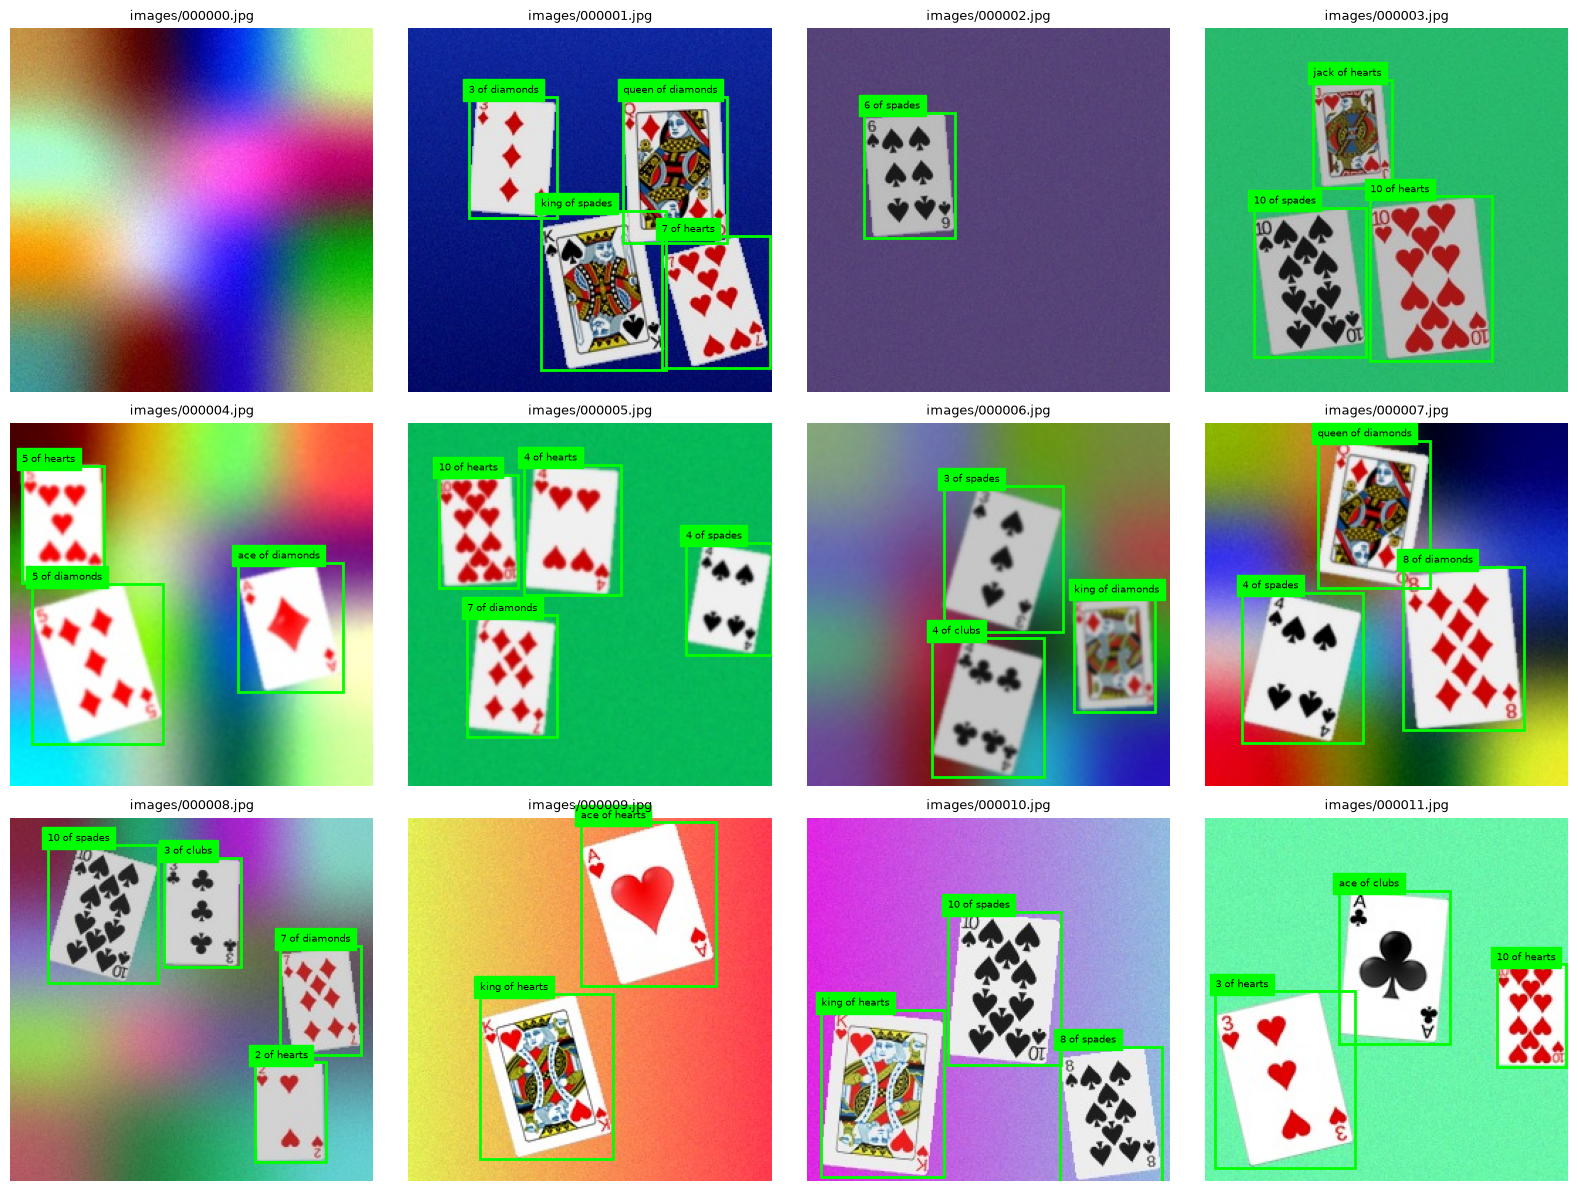

In [2]:
def show(ax, item):
    ax.imshow(Image.open(f"{DATA_DIR}/{SPLIT}/{item['image']}"))
    for card in item["cards"]:
        x1, y1, x2, y2 = card["box"]
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
        ax.text(x1, y1 - 3, card["name"], color="black", fontsize=7, backgroundcolor="lime")
    ax.set_title(item["image"], fontsize=9)
    ax.axis("off")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, item in zip(axes.flat, items):
    show(ax, item)
plt.tight_layout()

## 2. Les déformations, une par une

On rejoue ici les étapes de [scene.py](scene.py) séparément, avec les mêmes fonctions que la génération, pour voir l'effet de chacune.

### 2.1 Une carte, de l'image d'origine à sa boîte

Le fond gris montre les zones transparentes. Le cadre rouge en pointillés est le bord de l'image de la carte : à la dernière étape, il correspond exactement à la boîte enregistrée.

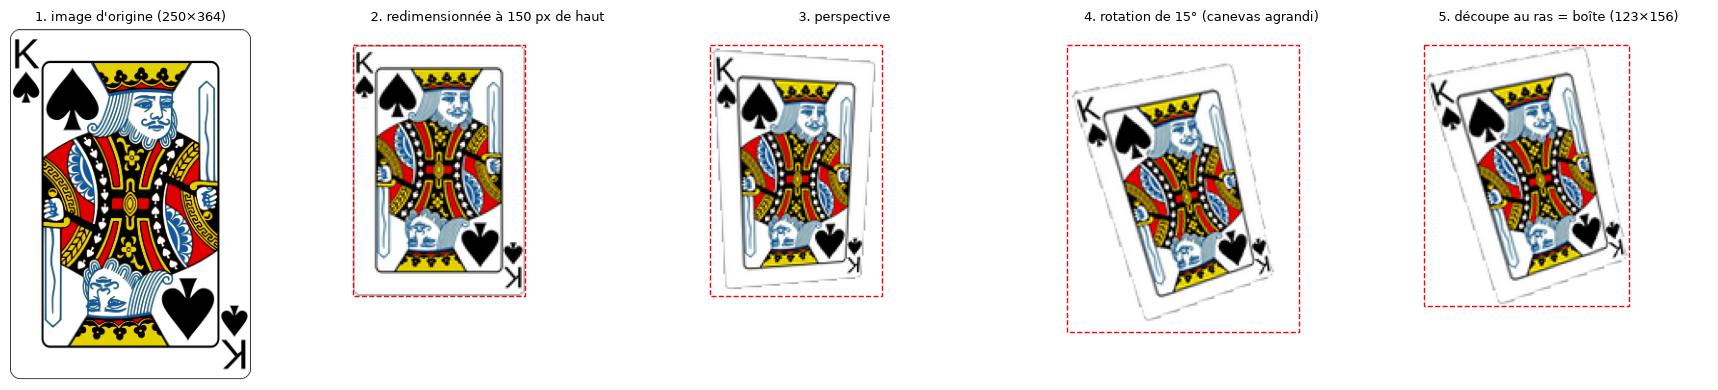

In [3]:
import numpy as np
from PIL import ImageEnhance, ImageFilter

from scratch.dataset_generation.cards import DECK
from scratch.dataset_generation.scene import (
    MAX_CARD_HEIGHT, MIN_CARD_HEIGHT, load_card_images, perspective, place_cards, random_background,
)

card_images = load_card_images()
card = next(c for c in DECK if c.name == "king of spades")
rng = np.random.default_rng(3)

original = card_images[card]
resized = original.resize((round(original.width * 150 / original.height), 150), Image.LANCZOS)
warped = perspective(resized, rng, 0.15)
rotated = warped.rotate(15, resample=Image.BICUBIC, expand=True)
cropped = rotated.crop(rotated.getchannel("A").getbbox())

def show_sprite(ax, sprite, title):
    ax.set_facecolor("lightgray")
    ax.imshow(sprite)
    ax.add_patch(patches.Rectangle((-0.5, -0.5), sprite.width, sprite.height, fill=False, edgecolor="red", linestyle="--"))
    ax.set_xlim(-10, max(sprite.width, 160) + 10)
    ax.set_ylim(max(sprite.height, 190) + 10, -10)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

steps = [
    (original, f"1. image d'origine ({original.width}×{original.height})"),
    (resized, "2. redimensionnée à 150 px de haut"),
    (warped, "3. perspective"),
    (rotated, "4. rotation de 15° (canevas agrandi)"),
    (cropped, f"5. découpe au ras = boîte ({cropped.width}×{cropped.height})"),
]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].set_facecolor("lightgray"); axes[0].imshow(original); axes[0].set_title(steps[0][1], fontsize=9); axes[0].axis("off")
for ax, (sprite, title) in zip(axes[1:], steps[1:]):
    show_sprite(ax, sprite, title)
plt.tight_layout()

### 2.2 La perspective

Chaque coin est rapproché du centre de 0 à 15 % de la largeur et de la hauteur, au hasard : la carte semble vue en biais. Huit tirages sur la même carte :

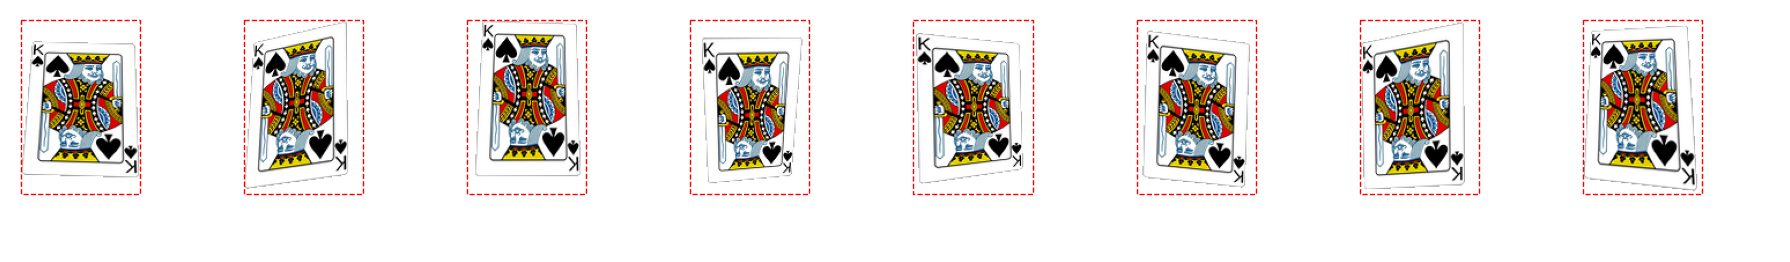

In [4]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for ax in axes:
    show_sprite(ax, perspective(resized, rng, 0.15), "")
plt.tight_layout()

### 2.3 La taille des cartes

Une hauteur est tirée par image, entre 50 px et un maximum qui dépend du nombre de cartes. Ligne du haut : la taille minimale ; ligne du bas : la taille maximale, pour 1 à 5 cartes.

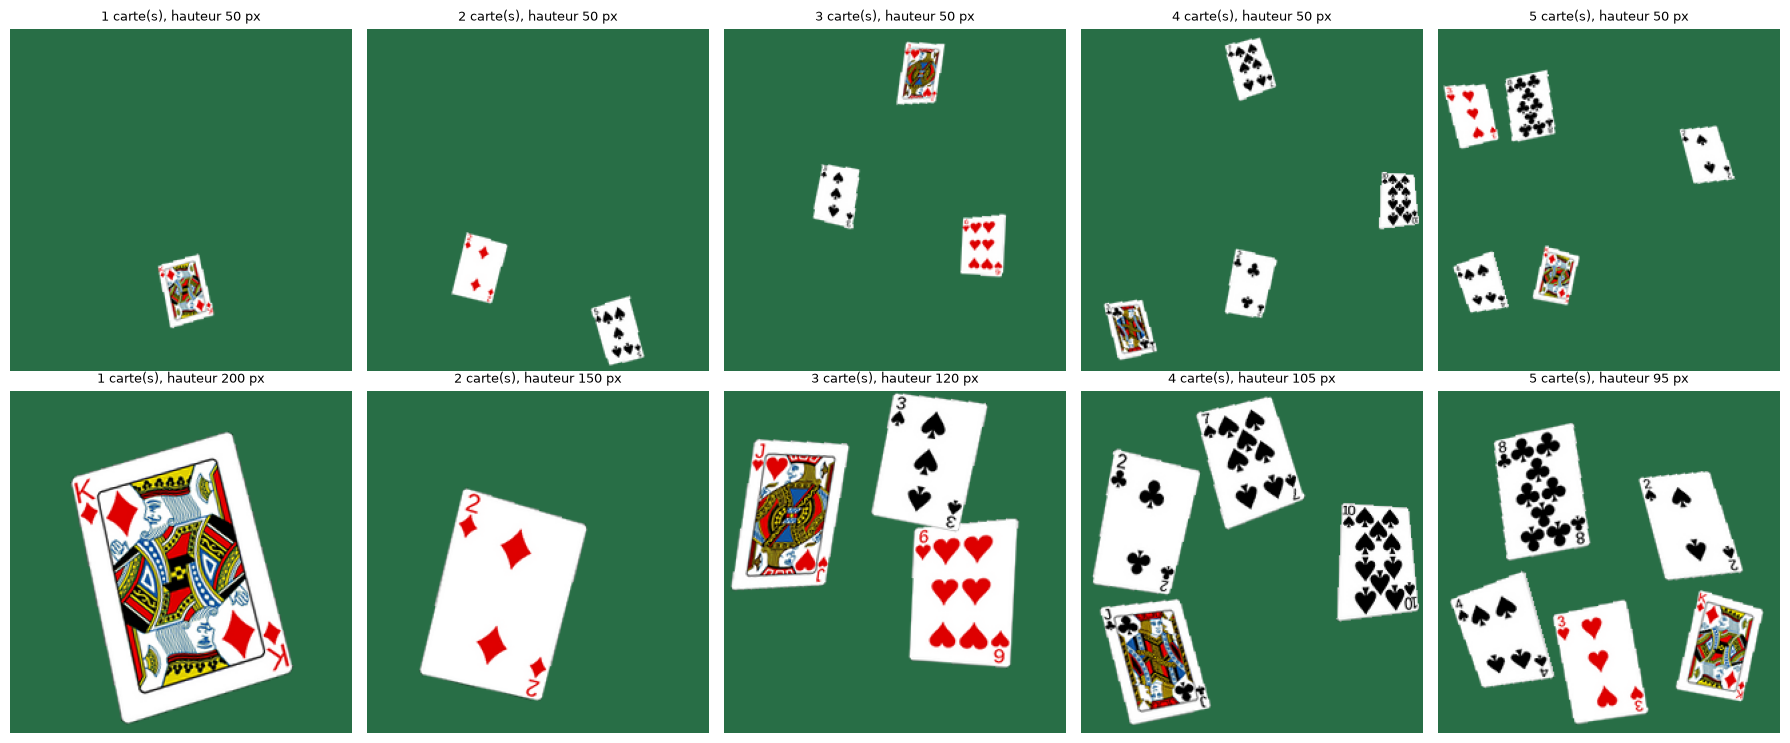

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for col, n in enumerate(range(1, 6)):
    for row, height in enumerate([MIN_CARD_HEIGHT, MAX_CARD_HEIGHT[n]]):
        rng = np.random.default_rng(n)
        scene = Image.new("RGB", (256, 256), (40, 110, 70))
        place_cards(scene, card_images, rng, n, height, max_rotation=20, max_perspective=0.15, max_overlap=0.1)
        axes[row, col].imshow(scene)
        axes[row, col].set_title(f"{n} carte(s), hauteur {height} px", fontsize=9)
        axes[row, col].axis("off")
plt.tight_layout()

### 2.4 Les trois types de fond

Couleur unie, dégradé (vertical ou horizontal) ou taches de couleur floues, avec une chance sur trois chacun. Deux exemples de chaque :

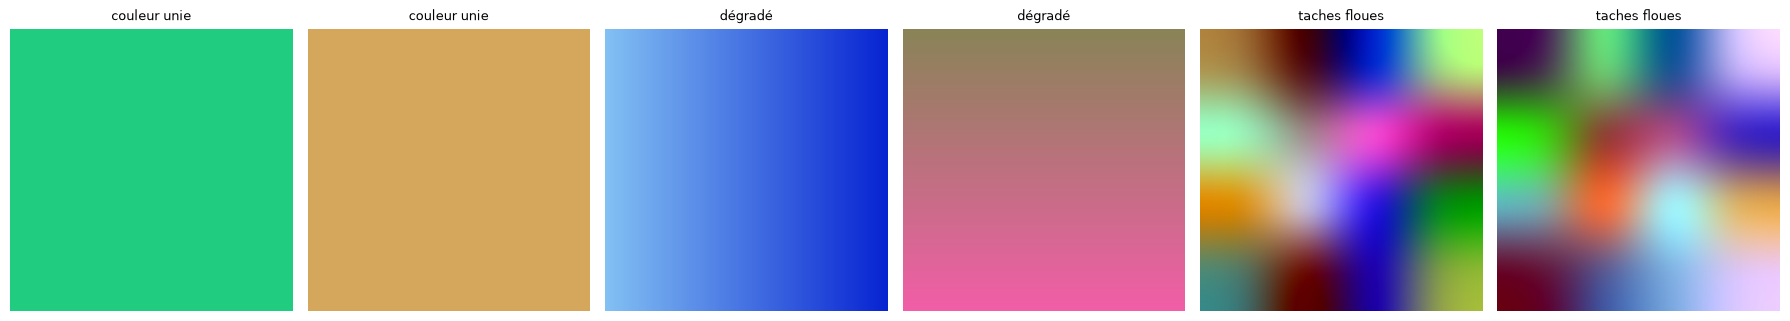

In [6]:
# random_background() tire d'abord le type de fond : on cherche des graines qui donnent chaque type
names = {0: "couleur unie", 1: "dégradé", 2: "taches floues"}
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
ax_iter = iter(axes)
for kind in range(3):
    seeds = [s for s in range(100) if np.random.default_rng(s).integers(3) == kind][:2]
    for seed in seeds:
        ax = next(ax_iter)
        ax.imshow(random_background(np.random.default_rng(seed), 256))
        ax.set_title(names[kind], fontsize=9)
        ax.axis("off")
plt.tight_layout()

### 2.5 Les retouches de l'image entière

Appliquées après avoir posé les cartes : luminosité et contraste (facteur entre 0,7 et 1,3), flou (sur 30 % des images, rayon 0,3 à 1,2 px), puis grain (bruit d'écart-type 6). Chaque retouche est montrée seule, à ses valeurs extrêmes. Le grain est montré en zoom.

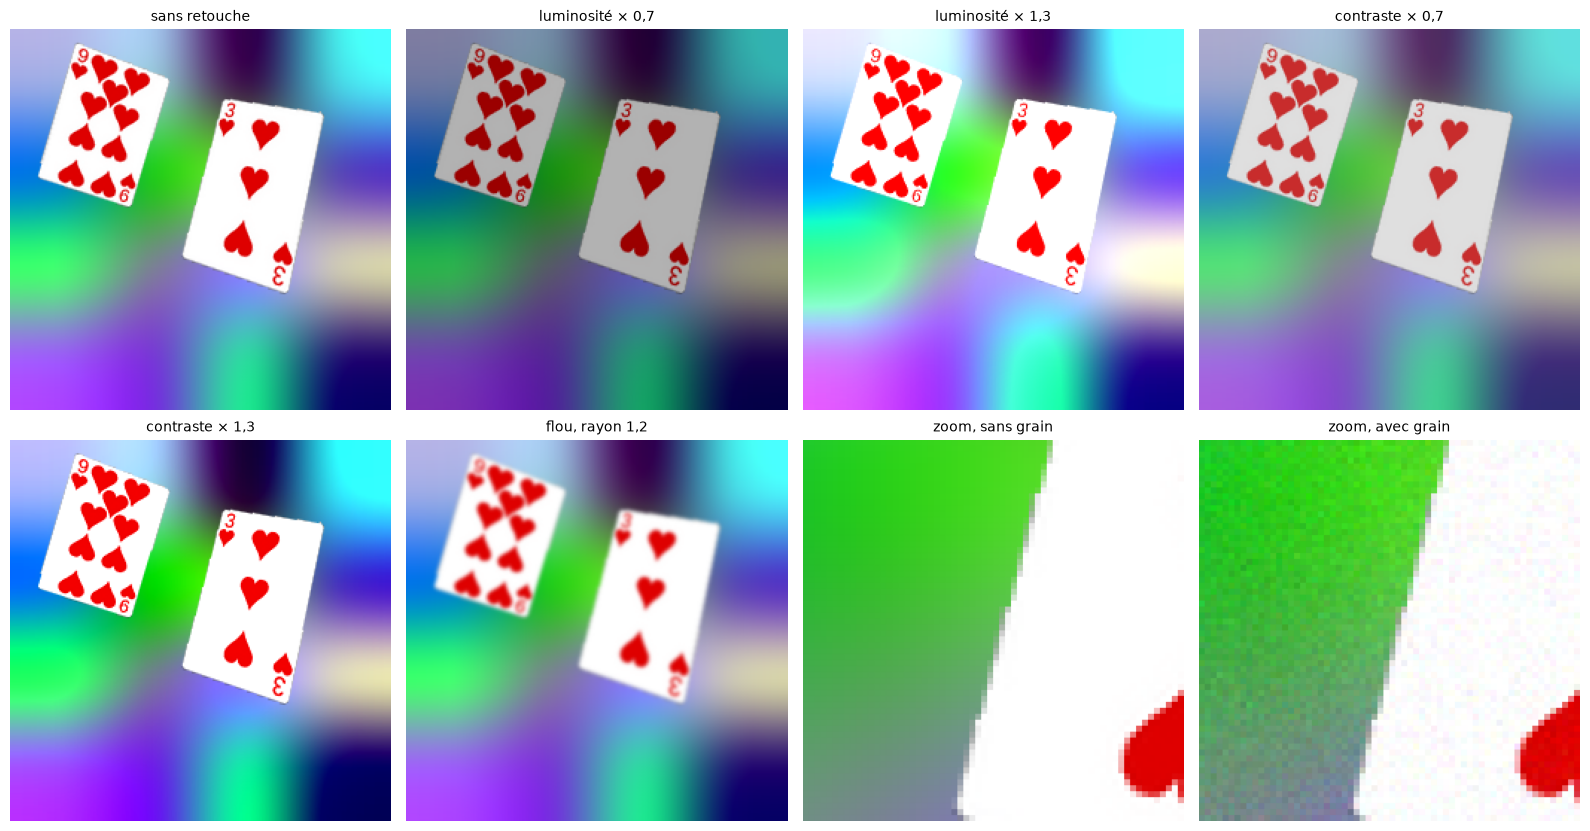

In [7]:
rng = np.random.default_rng(7)
base = random_background(rng, 256)
place_cards(base, card_images, rng, 2, 130, max_rotation=20, max_perspective=0.15, max_overlap=0.1)

def add_grain(image, sigma=6):
    array = np.asarray(image, dtype=np.float32) + np.random.default_rng(0).normal(0, sigma, (image.height, image.width, 3))
    return Image.fromarray(np.clip(array, 0, 255).astype(np.uint8))

zoom = lambda image: image.crop((90, 90, 154, 154)).resize((256, 256), Image.NEAREST)
variants = [
    (base, "sans retouche"),
    (ImageEnhance.Brightness(base).enhance(0.7), "luminosité × 0,7"),
    (ImageEnhance.Brightness(base).enhance(1.3), "luminosité × 1,3"),
    (ImageEnhance.Contrast(base).enhance(0.7), "contraste × 0,7"),
    (ImageEnhance.Contrast(base).enhance(1.3), "contraste × 1,3"),
    (base.filter(ImageFilter.GaussianBlur(1.2)), "flou, rayon 1,2"),
    (zoom(base), "zoom, sans grain"),
    (zoom(add_grain(base)), "zoom, avec grain"),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (image, title) in zip(axes.flat, variants):
    ax.imshow(image)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()

## 3. Statistiques

Les cartes sont tirées au hasard, donc leur nombre d'apparitions varie autour de la moyenne. L'écart-type attendu par le seul hasard vaut environ √(moyenne) : il devient négligeable en proportion quand le dataset grandit.

Apparitions par carte : min 8, max 22, moyenne 14.2 (52 cartes : True)
Écart-type observé : 3.5 ; attendu par le hasard : 3.8


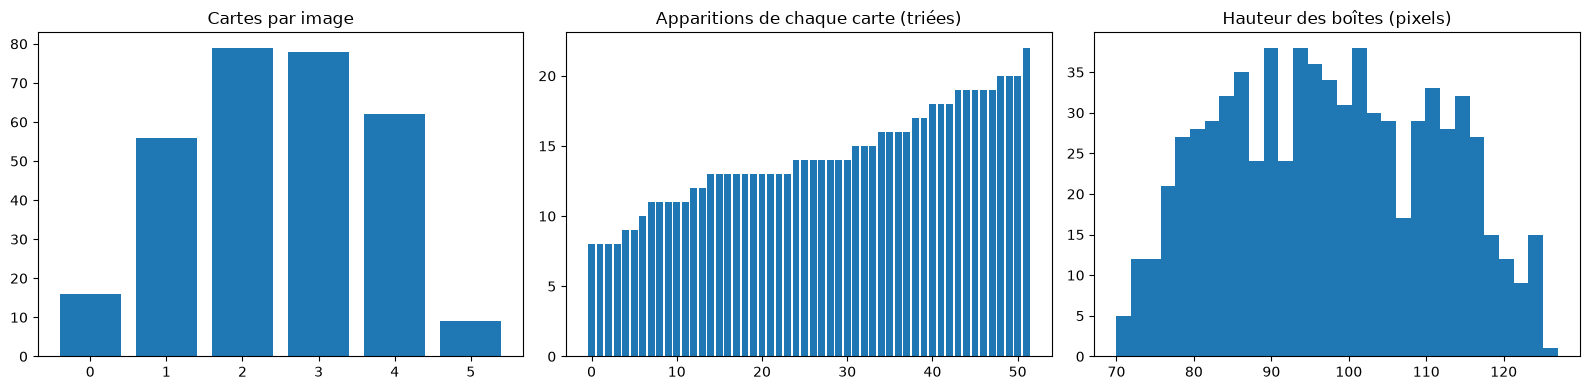

In [8]:
cards_per_image = Counter(len(item["cards"]) for item in items)
card_counts = Counter(card["name"] for item in items for card in item["cards"])
heights = [card["box"][3] - card["box"][1] for item in items for card in item["cards"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar([str(k) for k in sorted(cards_per_image)], [cards_per_image[k] for k in sorted(cards_per_image)])
axes[0].set_title("Cartes par image")
axes[1].bar(range(len(card_counts)), sorted(card_counts.values()))
axes[1].set_title("Apparitions de chaque carte (triées)")
axes[2].hist(heights, bins=30)
axes[2].set_title("Hauteur des boîtes (pixels)")
plt.tight_layout()

mean = sum(card_counts.values()) / 52
print(f"Apparitions par carte : min {min(card_counts.values())}, max {max(card_counts.values())}, moyenne {mean:.1f} (52 cartes : {len(card_counts) == 52})")
print(f"Écart-type observé : {np.std(list(card_counts.values())):.1f} ; attendu par le hasard : {np.sqrt(mean):.1f}")